In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
membership = pd.read_excel("Dataset/Membership.xlsx")
movie_master = pd.read_excel("Dataset/Movie_Master.xlsx")
user_mapping = pd.read_excel("Dataset/User_Mapping.xlsx")
view_history = pd.read_excel("Dataset/View_History.xlsx")

> Membership과 User_Mapping의 USER_KEY 대응하기

1. Membership의 "user_no" → "USER_KEY"
2. User_Mapping의 "uid" → "USER_KEY"

In [3]:
membership.rename(columns={"user_no" : "USER_KEY"}, inplace=True)
user_mapping.rename(columns={"uid" : "USER_KEY"}, inplace=True)

> User_Mapping과 View_History의 USER_NUM 대응하기

1. User_Mapping의 "USER_ID" → "USER_NUM"
2. View_History의 "USER_ID" → "USER_NUM"

In [4]:
user_mapping.rename(columns={"USER_ID" : "USER_NUM"}, inplace=True)
view_history.rename(columns={"USER_ID" : "USER_NUM"}, inplace=True)

> Membership에서 concurrent_streams에 따라 plan 컬럼 생성, 대응되는 플랜 삽입

사용하는 함수: .map()

concurrent_streams → 1, plan = "Basic"  
concurrent_streams → 2, plan = "Standard"  
concurrent_streams → 4, plan = "Premium"  

In [5]:
membership["concurrent_streams"] = pd.to_numeric(membership["concurrent_streams"], errors="coerce")
membership["plan"] = membership["concurrent_streams"].map({
    1: "Basic",
    2: "Standard",
    4: "Premium"
}).fillna("")


> EDA1. 각 Plan별로 결제금액(Amount)의 분포 알아보기

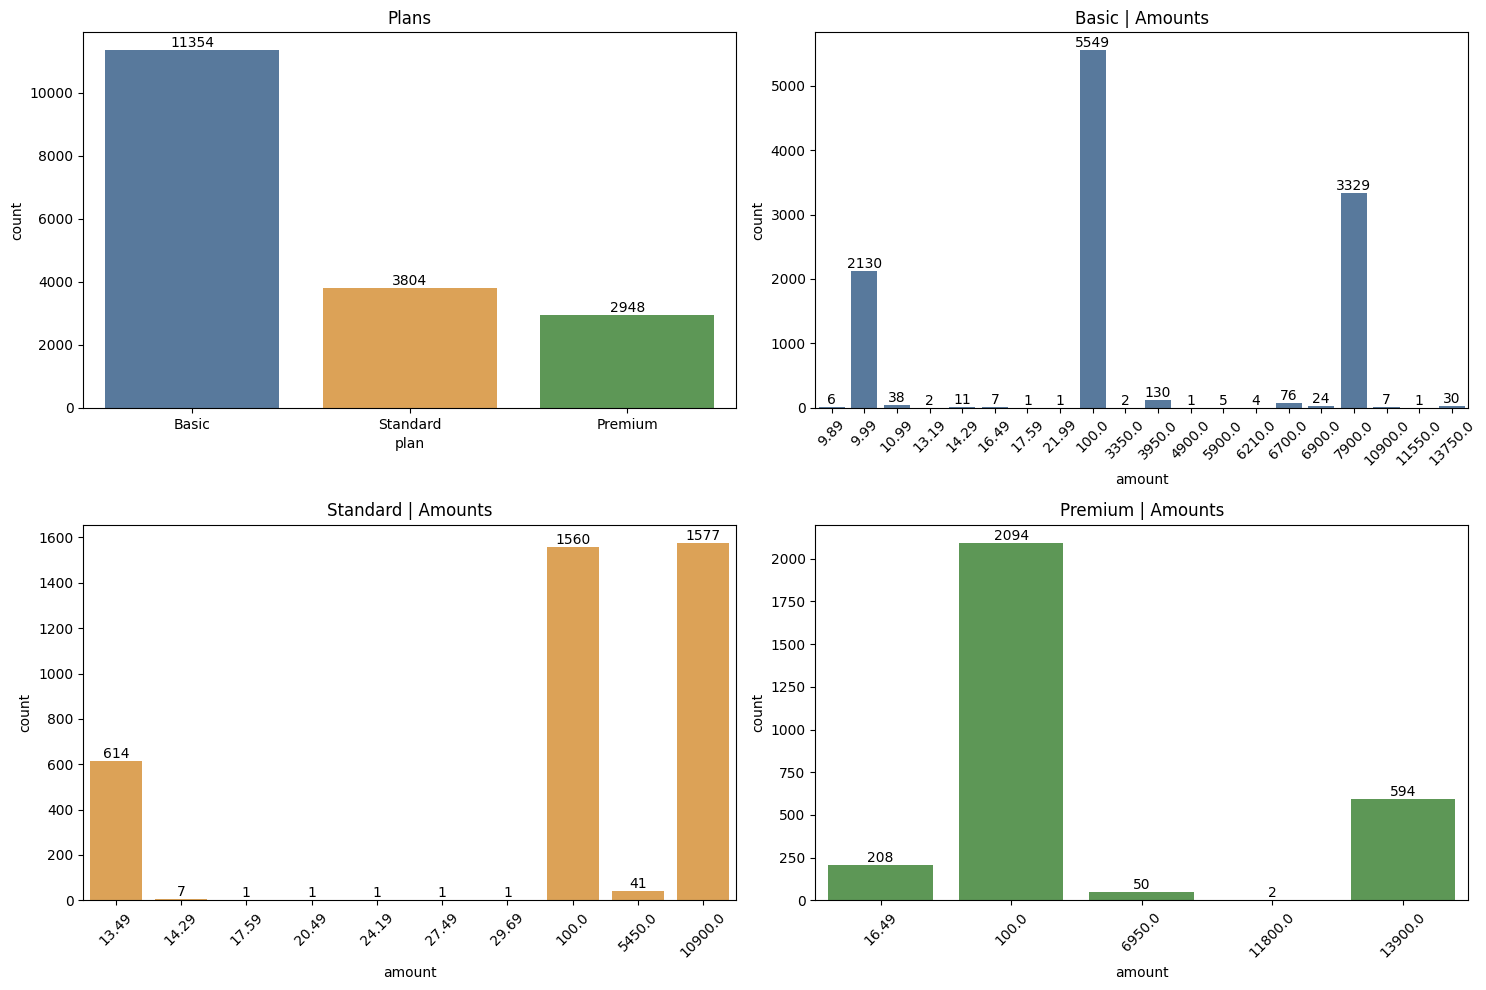

In [6]:
plan_palette = {"Basic": "#4C78A8", "Standard": "#F2A541", "Premium": "#54A24B"}
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=membership, x="plan", hue="plan", ax=axes[0][0], palette=plan_palette, order=["Basic", "Standard", "Premium"])
axes[0][0].set_title("Plans")
for container in axes[0][0].containers:
    axes[0][0].bar_label(container)

sns.countplot(data=membership[membership["plan"] == "Basic"], x="amount", ax=axes[0][1], color=plan_palette["Basic"])
axes[0][1].set_title("Basic | Amounts")
axes[0][1].tick_params(axis="x", labelrotation=45)
for container in axes[0][1].containers:
    axes[0][1].bar_label(container)

sns.countplot(data=membership[membership["plan"] == "Standard"], x="amount", ax=axes[1][0], color=plan_palette["Standard"])
axes[1][0].set_title("Standard | Amounts")
axes[1][0].tick_params(axis="x", labelrotation=45)
for container in axes[1][0].containers:
    axes[1][0].bar_label(container)

sns.countplot( data=membership[membership["plan"] == "Premium"], x="amount", ax=axes[1][1], color=plan_palette["Premium"])
axes[1][1].set_title("Premium | Amounts")
axes[1][1].tick_params(axis="x", labelrotation=45)
for container in axes[1][1].containers:
    axes[1][1].bar_label(container)

plt.tight_layout()

> Explain01. amount별로 count 집계, 그리고 각 amount의 추정 plan을 기입한 excel

In [ ]:
Explain01_amount_count = membership["amount"].value_counts().reset_index()
Explain01_amount_count.columns = ["amount", "count"]
Explain01_amount_count["추정 요금제"] = ""
Explain01_amount_count["비고"] = ""
# Explain01_amount_count.to_excel("Dataset/_Explain01_amount_count.xlsx", index=False)

> 이제는 못 참겠다, 그냥 이상치 날려버리자.

> EDA 2. concurrent_streams가 3이나 NaN이 전체에서 몇 퍼센트를 차지하는가?

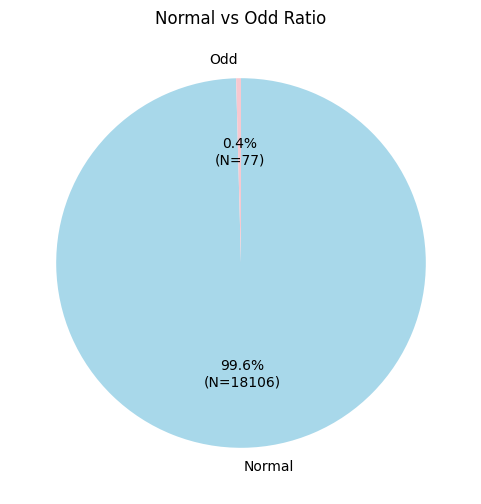

In [8]:
import matplotlib.pyplot as plt

mask = membership["concurrent_streams"].isin([1, 2, 4])

normal = membership[mask]
odd = membership[~mask]

sizes = [len(normal), len(odd)]
labels = ["Normal", "Odd"]
colors = ["#A8D8EA", "#F7C8D0"]  # 파스텔 블루, 파스텔 핑크

def autopct_with_count(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n(N={count})"
    return inner

plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct=autopct_with_count(sizes),
    startangle=90,
    counterclock=False
)
plt.title("Normal vs Odd Ratio")
plt.show()


> Concurrent_streams가 3이거나 NaN인 77개의 행을 날려버렸음.  
- Outlier_Removed_01_Membership.xlsx로 저장

In [12]:
removed_odd = odd.copy()
Outlier_Removed_01_Membership = membership[membership["concurrent_streams"].isin([1, 2, 4])].copy()
Outlier_Removed_01_Membership["concurrent_streams"].value_counts(dropna=False).sort_index()
Outlier_Removed_01_Membership.to_excel("Dataset/_Outlier_Removed_01_Membership.xlsx")